
# Predicción de Avalúos Catastrales
**Proyecto de Analítica Predictiva (CRISP-DM)**

**Integrantes:** Juan Sebastián Sánchez Hincapié

---

## 1. Entendimiento del negocio

### 1.1 Descripción del Problema

El avalúo catastral es un valor económico asignado a cada predio que sirve como base para el cálculo de impuestos y procesos de planeación territorial.
Actualmente, la estimación de este valor depende de múltiples variables físicas, económicas y de localización del predio.

El problema consiste en **predecir el avalúo catastral (`AVALUO`) de un predio urbano a partir de sus características registradas en el catastro**, utilizando técnicas de analítica predictiva.

Esto permitirá a las entidades públicas mejorar la estimación de avalúos, validar información y apoyar la planeación fiscal.

---

### 1.2 Diseño de Solución

- **Tipo de análisis:** Predictivo
- **Tipo de aprendizaje:** Supervisado (Regresión)
- **Método elegido:** Random Forest (Regresión)

**Justificación:**
Random Forest es un modelo de ensamble basado en árboles de decisión.
Se adapta bien a datos heterogéneos con variables numéricas y categóricas, maneja outliers y es capaz de capturar relaciones no lineales entre variables.
Estas características lo hacen ideal para la predicción de avalúos catastrales, donde los valores pueden variar significativamente según ubicación, área y destino económico.

**Métricas de evaluación:**

- **MAE** (Mean Absolute Error): para interpretar el error medio en pesos colombianos.
- **RMSE** (Root Mean Squared Error): para evaluar el impacto de errores grandes en avalúos altos.
- **MAPE** (Mean Absolute Percentage Error): para medir el porcentaje de error relativo al valor real del predio.

---

## 2. Entendimiento de los datos

### Diccionario de datos

---

### 2.1 Variable dependiente

La variable que se desea predecir, desconocida en el futuro.

| Variable | Descripción                                                                             |
| -------- | --------------------------------------------------------------------------------------- |
| AVALUO   | Valor catastral total del predio (suma del valor del terreno, construcciones y anexos). |

---

### 2.2 Variables independientes

Variables conocidas en el futuro, que permiten hacer la predicción de la variable dependiente.

| Variable          | Descripción                                                                               |
| ----------------- | ----------------------------------------------------------------------------------------- |
| AREA_CONSTRUCCION | Área construida del predio (en m²).                                                       |
| AREA_TERRENO      | Área total del terreno (en m²).                                                           |
| VALOR_TERR        | Valor monetario asignado al terreno.                                                      |
| VALOR_CONST       | Valor monetario asignado a las construcciones.                                            |
| DESTINO_ECONOMICO | Clasificación del uso económico del predio (residencial, comercial, institucional, etc.). |
| COMUNA            | Identificador de la comuna donde se ubica el predio.                                      |
| BARRIO            | Identificador o nombre del barrio donde se encuentra el predio.                           |
| AREA_ANEXO        | Área de construcciones anexas (garajes, depósitos, etc.).                                 |
| VALOR_ANEXO       | Valor monetario de las construcciones anexas.                                             |

---

### 2.3 Reglas de calidad

#### Variables numéricas

| Variable          | Valor mínimo\* | Valor máximo\* |
| ----------------- | -------------- | -------------- |
| AREA_CONSTRUCCION | 0 m²           | 2,000 m²       |
| AREA_TERRENO      | 1 m²           | 50,000 m²      |
| VALOR_TERR        | 100,000        | 5,000,000,000  |
| VALOR_CONST       | 0              | 5,000,000,000  |
| VALOR_ANEXO       | 0              | 500,000,000    |
| AVALUO            | 100,000        | 10,000,000,000 |

\*Valores definidos según entendimiento del negocio y rangos realistas para predios urbanos.

---

#### Variables categóricas

| Variable          | Valores posibles                                                 |
| ----------------- | ---------------------------------------------------------------- |
| DESTINO_ECONOMICO | {Residencial, Comercial, Industrial, Institucional, Mixto, Otro} |
| COMUNA            | Códigos numéricos (0001 – 0065)                                  |
| BARRIO            | Identificador o nombre de barrio (00-99)                         |

---

## 3. Preparación de datos

### Carga de datos y exploración inicial

In [3]:
import pandas as pd

# Cargar dataset
df = pd.read_csv('../data/historicos_2022.csv', decimal=',')

# Vista rápida
df.head()


,ID_PREDIO,NUMERO_PREDIAL_NACIONAL,COMUNA,BARRIO,MANZANA,TERRENO,PREDIO,VIGENCIA,DESCRIP_CONDICION_PROPIEDAD,ID_TERRENO,AREA_CONSTRUCCION,AREA_TERRENO,VALOR_TERR,VALOR_CONST,DESTINO_ECONOMICO,AVALUO,AREA_ANEXO,VALOR_ANEXO
0,885102,760010100177400690001903990475,17,74,69,1,475,1/1/2022,PH,1.774007e+11,12,4.0,3127957.56,7596468.36,411,10724425.92,0.0,0.00
1,915228,760010100177500980020901050102,17,75,98,20,102,1/1/2022,PH,1.775010e+11,55,36.0,28285291.44,58093902.18,2,86379193.62,0.0,0.00
2,2237,760010100021700870001000000001,2,17,87,1,1,1/1/2022,NPH,2.170087e+10,0,247.0,30493338.37,0.00,0,30493338.37,0.0,0.00
3,2239,760010100021700840001000000001,2,17,84,1,1,1/1/2022,NPH,2.170084e+10,0,147.0,18147857.25,0.00,0,18147857.25,0.0,0.00
4,9969,760010000560000030002500000003,56,0,3,2,3,1/1/2022,MEJORAS POR EDIFICACIONES EN TERRENO AJENO DE ...,5.600030e+09,250,0.0,0.00,48940140.93,1003,52008719.54,86.0,3068578.61


## 3.1 Selección de variables


Desde el conocimiento del negocio, seleccionamos las variables relevantes para predecir el **avalúo total (AVALUO)**:

- **Área Construcción (AREA_CONSTRUCCION)**
- **Área Terreno (AREA_TERRENO)**
- **Valor Terreno (VALOR_TERR)**
- **Valor Construcción (VALOR_CONST)**
- **Destino Económico (DESTINO_ECONOMICO)**
- **Comuna (COMUNA)**
- **Área Anexo (AREA_ANEXO)**
- **Valor Anexo (VALOR_ANEXO)**


## 3.2 Descripción estadística

In [4]:
cols_a_dropear = [
    'ID_PREDIO', 'NUMERO_PREDIAL_NACIONAL', 'TERRENO', 'PREDIO',
    'ID_TERRENO', 'MANZANA', 'DESCRIP_CONDICION_PROPIEDAD', 'VIGENCIA', 'BARRIO', 'VALOR_TERR',
    'VALOR_ANEXO', 'VALOR_CONST', 'DESTINO_ECONOMICO'
]

df_clean = df.drop(columns=cols_a_dropear)

df_clean.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
COMUNA,750068.0,1.596897e+01,1.408601e+01,1.00,6.000000e+00,15.00,1.900000e+01,6.500000e+01
AREA_CONSTRUCCION,750068.0,1.057390e+02,5.296782e+02,0.00,2.200000e+01,63.00,1.230000e+02,2.611130e+05
AREA_TERRENO,750068.0,7.073698e+02,4.605815e+04,0.00,1.200000e+01,52.00,1.050000e+02,2.626469e+07
AVALUO,750068.0,1.140164e+08,1.083046e+09,251.93,1.603440e+07,55382268.21,1.091646e+08,6.297286e+11
AREA_ANEXO,750068.0,8.231801e+00,3.537211e+02,0.00,0.000000e+00,0.00,0.000000e+00,1.962080e+05


In [5]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750068 entries, 0 to 750067
Data columns (total 5 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   COMUNA             750068 non-null  int64  
 1   AREA_CONSTRUCCION  750068 non-null  int64  
 2   AREA_TERRENO       750068 non-null  float64
 3   AVALUO             750068 non-null  float64
 4   AREA_ANEXO         750068 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 28.6 MB


In [6]:
categorial_cols = [
    # 'DESTINO_ECONOMICO',
    'COMUNA']

for col in categorial_cols:
    df_clean[col] = df[col].astype('category')

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750068 entries, 0 to 750067
Data columns (total 5 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   COMUNA             750068 non-null  category
 1   AREA_CONSTRUCCION  750068 non-null  int64   
 2   AREA_TERRENO       750068 non-null  float64 
 3   AVALUO             750068 non-null  float64 
 4   AREA_ANEXO         750068 non-null  float64 
dtypes: category(1), float64(3), int64(1)
memory usage: 23.6 MB


## 3.3 Limpieza de atípicos

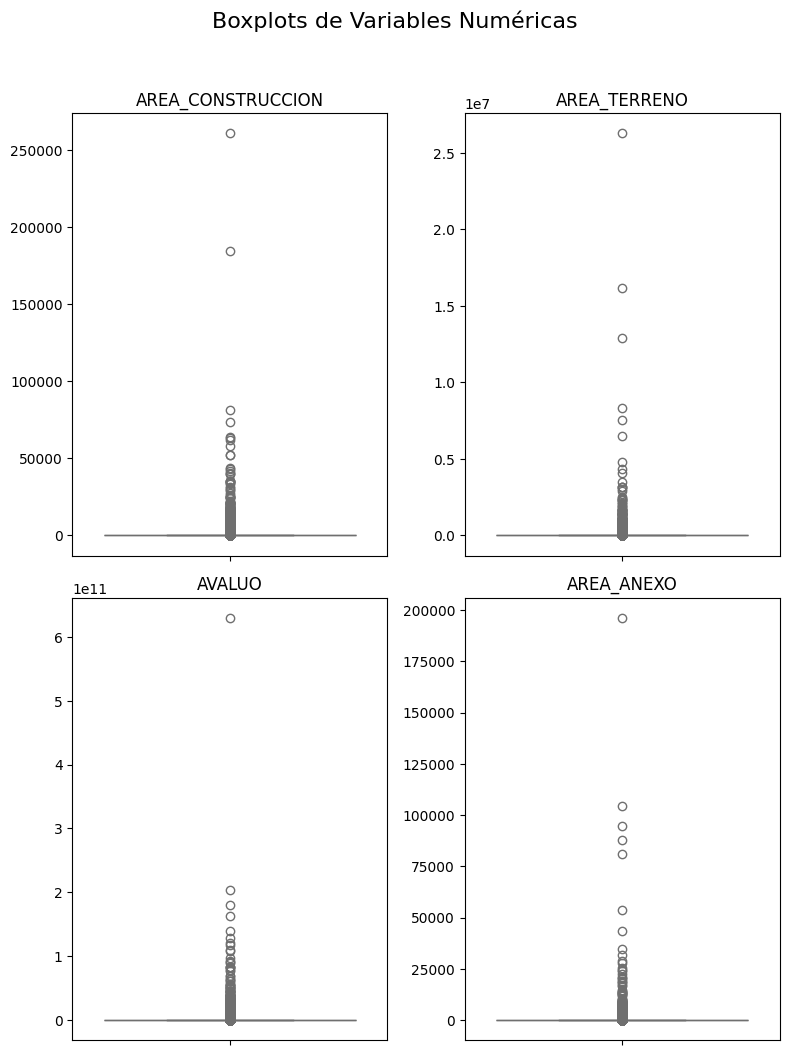

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


numeric_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns
num_plots = len(numeric_cols)


num_rows = 3

num_cols = int(np.ceil(num_plots / num_rows))


fig_width = num_cols * 4
fig_height = num_rows * 5

fig, axes = plt.subplots(num_rows, num_cols, figsize=(fig_width, fig_height))


axes = axes.flatten()


for i, col in enumerate(numeric_cols):

    sns.boxplot(y=df_clean[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel('')


for j in range(num_plots, num_rows * num_cols):
    fig.delaxes(axes[j])


plt.suptitle('Boxplots de Variables Numéricas', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [8]:
df_clean = df_clean[(df_clean['AVALUO'] <= 8e8) & (df_clean['AVALUO'] >= 1e8)]

In [9]:
cols_to_clean = [
    'AREA_CONSTRUCCION',
    'AREA_TERRENO',
    # 'AREA_ANEXO',
]

k = 1.5

for col in cols_to_clean:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = max(0, Q1 - k * IQR)
    upper_bound = Q3 + k * IQR

    # Winsorización: recortar a los límites
    before_outliers = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
    df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)
    after_outliers = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()

    print(f"{col}: {before_outliers} valores extremos recortados (k={k})")

display(df_clean.head())


AREA_CONSTRUCCION: 6260 valores extremos recortados (k=1.5)
AREA_TERRENO: 14357 valores extremos recortados (k=1.5)


,COMUNA,AREA_CONSTRUCCION,AREA_TERRENO,AVALUO,AREA_ANEXO
9,54,483,360.0,6.143075e+08,152.0
11,54,483,360.0,7.285487e+08,125.0
12,64,483,360.0,4.661896e+08,0.0
16,64,91,360.0,1.390537e+08,0.0
24,22,84,34.0,2.266846e+08,0.0


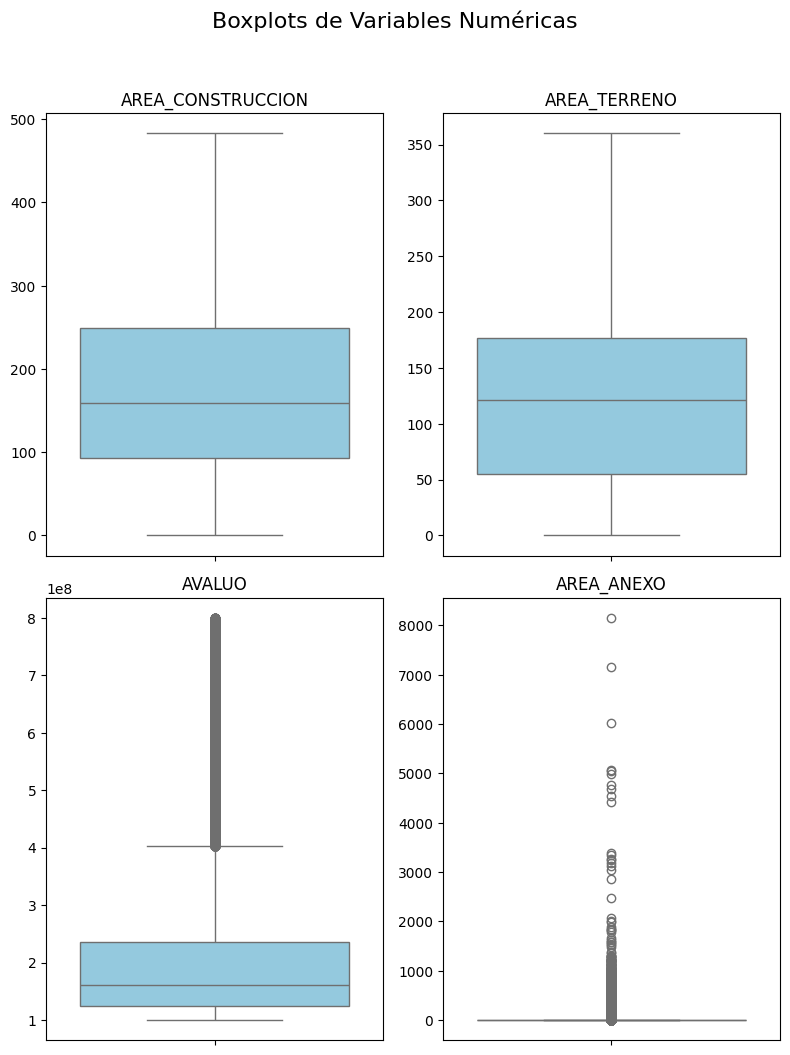

In [10]:
numeric_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns
num_plots = len(numeric_cols)


num_rows = 3

num_cols = int(np.ceil(num_plots / num_rows))


fig_width = num_cols * 4
fig_height = num_rows * 5

fig, axes = plt.subplots(num_rows, num_cols, figsize=(fig_width, fig_height))


axes = axes.flatten()


for i, col in enumerate(numeric_cols):

    sns.boxplot(y=df_clean[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel('')


for j in range(num_plots, num_rows * num_cols):
    fig.delaxes(axes[j])


plt.suptitle('Boxplots de Variables Numéricas', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [9]:
df_clean.shape

(200598, 5)

## 3.4 Limpieza de nulos

In [11]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
df_imputed = imputer.fit_transform(df_clean.select_dtypes(include=['float64', 'int64']))

df_clean[df_clean.select_dtypes(include=['float64', 'int64']).columns] = df_imputed

display(df_clean.head())

,COMUNA,AREA_CONSTRUCCION,AREA_TERRENO,AVALUO,AREA_ANEXO
9,54,483.0,360.0,6.143075e+08,152.0
11,54,483.0,360.0,7.285487e+08,125.0
12,64,483.0,360.0,4.661896e+08,0.0
16,64,91.0,360.0,1.390537e+08,0.0
24,22,84.0,34.0,2.266846e+08,0.0


## 3.5 Creación de nuevas variables

In [12]:
from sklearn.preprocessing import OneHotEncoder
import joblib

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_comuna = encoder.fit_transform(df_clean[['COMUNA']])

encoded_comuna_df = pd.DataFrame(
    encoded_comuna,
    columns=encoder.get_feature_names_out(['COMUNA']),
    index=df_clean.index
)
df_encoded = pd.concat([df_clean, encoded_comuna_df], axis=1)

display(df_encoded.head())

# Save the encoder
joblib.dump(encoder, 'onehotencoder.pkl')

,COMUNA,AREA_CONSTRUCCION,AREA_TERRENO,AVALUO,AREA_ANEXO,COMUNA_1,COMUNA_2,COMUNA_3,COMUNA_4,COMUNA_5,...,COMUNA_56,COMUNA_57,COMUNA_58,COMUNA_59,COMUNA_60,COMUNA_61,COMUNA_62,COMUNA_63,COMUNA_64,COMUNA_65
9,54,483.0,360.0,6.143075e+08,152.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11,54,483.0,360.0,7.285487e+08,125.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12,64,483.0,360.0,4.661896e+08,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
16,64,91.0,360.0,1.390537e+08,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
24,22,84.0,34.0,2.266846e+08,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


['onehotencoder.pkl']

#### Multi-label One-Hot Encoding

In [12]:

# multi_label_col = 'DESTINO_ECONOMICO'
# encoders = {}

# df_encoded[multi_label_col] = df_encoded[multi_label_col].astype(str).fillna('')


# all_categories = df_encoded[multi_label_col].str.split(pat=r',\s*|\s*,\s*', expand=True).stack().unique()
# all_categories = sorted([c for c in all_categories if c and c != 'nan'])


# ohe_destino = pd.DataFrame()

# for category in all_categories:

#     col_name = f'{multi_label_col}_{category}'

#     ohe_destino[col_name] = df_encoded[multi_label_col].str.contains(category, regex=False).astype(int)


# df_encoded = pd.concat([df_encoded, ohe_destino], axis=1)
# encoders[f'mlb_{multi_label_col}'] = all_categories
# df_encoded = df_encoded.drop(multi_label_col, axis=1)


In [13]:
df_encoded.head()

,COMUNA,AREA_CONSTRUCCION,AREA_TERRENO,AVALUO,AREA_ANEXO,COMUNA_1,COMUNA_2,COMUNA_3,COMUNA_4,COMUNA_5,...,COMUNA_56,COMUNA_57,COMUNA_58,COMUNA_59,COMUNA_60,COMUNA_61,COMUNA_62,COMUNA_63,COMUNA_64,COMUNA_65
9,54,483.0,360.0,6.143075e+08,152.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11,54,483.0,360.0,7.285487e+08,125.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12,64,483.0,360.0,4.661896e+08,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
16,64,91.0,360.0,1.390537e+08,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
24,22,84.0,34.0,2.266846e+08,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
# Muestra las primeras 5 filas y solo las columnas de comuna
destino_cols = [col for col in df_encoded.columns if col.startswith('COMUNA_')]

# Muestra un resumen de estas columnas
print(f"Columnas encontradas para Comuna: {len(destino_cols)}")
display(df_encoded[destino_cols].head())

Columnas encontradas para Comuna: 37


,COMUNA_1,COMUNA_2,COMUNA_3,COMUNA_4,COMUNA_5,COMUNA_6,COMUNA_7,COMUNA_8,COMUNA_9,COMUNA_10,...,COMUNA_56,COMUNA_57,COMUNA_58,COMUNA_59,COMUNA_60,COMUNA_61,COMUNA_62,COMUNA_63,COMUNA_64,COMUNA_65
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
24,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
# # Muestra las primeras 5 filas y solo las columnas de destino económico
# destino_cols2 = [col for col in df_encoded.columns if col.startswith('DESTINO_ECONOMICO_')]

# # Muestra un resumen de estas columnas
# print(f"Columnas encontradas para Destino Económico: {len(destino_cols2)}")
# display(df_encoded[destino_cols2].head())

## 3.6 Análisis de relaciones

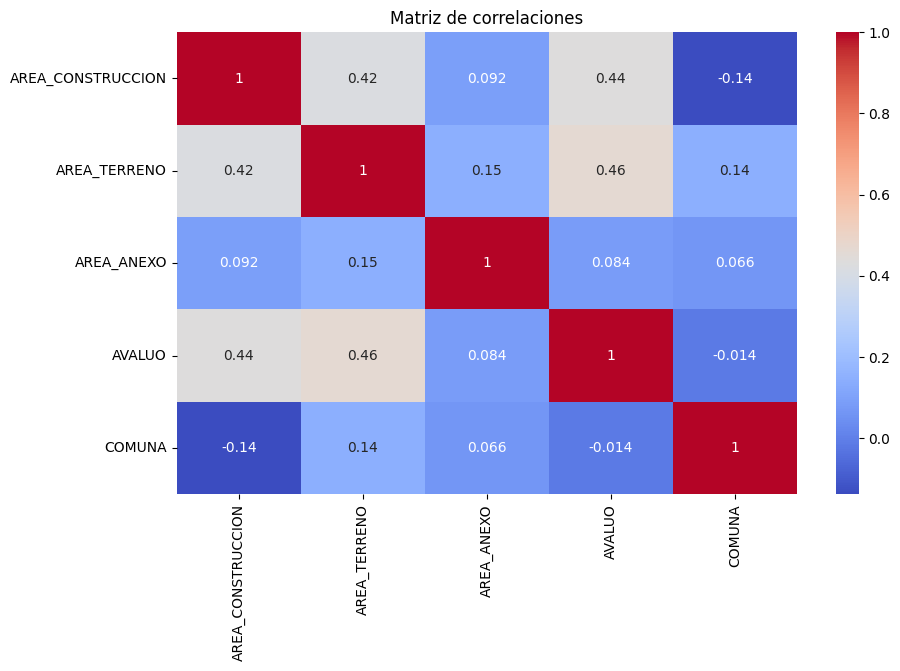

In [14]:

import seaborn as sns
import matplotlib.pyplot as plt

# Matriz de correlaciones
plt.figure(figsize=(10,6))
sns.heatmap(df_encoded[['AREA_CONSTRUCCION','AREA_TERRENO','AREA_ANEXO','AVALUO','COMUNA']].corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de correlaciones')
plt.show()


In [15]:
from sklearn.preprocessing import StandardScaler
import joblib

features_to_scale = [
    'AREA_CONSTRUCCION',
    'AREA_TERRENO',
    'AREA_ANEXO',
]

scaler = StandardScaler()


df_encoded[features_to_scale] = scaler.fit_transform(df_encoded[features_to_scale])
joblib.dump(scaler, 'final_area_scaler.pkl')

['final_area_scaler.pkl']

## 4. Modelamiento y evaluación

### 4.1 Configuración y selección de métodos de machine learning


In [16]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df_encoded.drop('AVALUO', axis=1)
y = df_encoded['AVALUO']

# Split the data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (140418, 41)
X_test shape: (60180, 41)
y_train shape: (140418,)
y_test shape: (60180,)


In [17]:
from sklearn.impute import KNNImputer

# Impute missing values in X_train and X_test using a separate imputer
imputer_X = KNNImputer(n_neighbors=5)
X_train_imputed = imputer_X.fit_transform(X_train)
X_test_imputed = imputer_X.transform(X_test)

# Impute missing values in y_train using another imputer
imputer_y = KNNImputer(n_neighbors=5)
y_train_imputed = imputer_y.fit_transform(y_train.values.reshape(-1, 1))

In [20]:
from sklearn.neural_network import MLPRegressor

# Create an MLPRegressor model with default parameters
mlp_model = MLPRegressor(random_state=42, max_iter=1000)

In [21]:
# Now train the model with the imputed data
mlp_model.fit(X_train_imputed, y_train_imputed.ravel())

c:\Users\juans\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,loss,'squared_error'
,hidden_layer_sizes,"(100,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True


In [27]:
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions on the imputed test set
y_pred = mlp_model.predict(X_test_imputed)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Squared Error: 20261297394366532.00
R-squared: -0.28


In [29]:
from sklearn.metrics import mean_absolute_percentage_error

# Calculate MAPE
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}")

Mean Absolute Percentage Error (MAPE): 0.40


In [18]:
from sklearn.neighbors import KNeighborsRegressor

# Create a KNN Regressor model
knn_model = KNeighborsRegressor(n_neighbors=5)

In [19]:
# Train the KNN model
knn_model.fit(X_train_imputed, y_train_imputed.ravel())

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [20]:
from sklearn.metrics import mean_absolute_percentage_error

# Make predictions on the imputed test set using the KNN model
y_pred_knn = knn_model.predict(X_test_imputed)

# Calculate MAPE for the KNN model
mape_knn = mean_absolute_percentage_error(y_test, y_pred_knn)

print(f"Mean Absolute Percentage Error (MAPE) for KNN: {mape_knn:.2f}")

Mean Absolute Percentage Error (MAPE) for KNN: 0.13


In [21]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)

In [22]:
dt_model.fit(X_train_imputed, y_train_imputed.ravel())

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [23]:
y_pred_dt = dt_model.predict(X_test_imputed)

In [24]:
mape_dt = mean_absolute_percentage_error(y_test, y_pred_dt)
print(f"Mean Absolute Percentage Error (MAPE) for Decision Tree: {mape_dt:.2f}")

Mean Absolute Percentage Error (MAPE) for Decision Tree: 0.15


In [26]:
from sklearn.linear_model import LinearRegression

# Crear el modelo de regresión lineal
linear_model = LinearRegression()

# Entrenar el modelo con los datos imputados
linear_model.fit(X_train_imputed, y_train_imputed.ravel())

# Predecir sobre el conjunto de prueba
y_pred_linear = linear_model.predict(X_test_imputed)

# Calcular el MAPE
mape_linear = mean_absolute_percentage_error(y_test, y_pred_linear)
print(f"Mean Absolute Percentage Error (MAPE) para Regresión Lineal: {mape_linear:.2f}")

Mean Absolute Percentage Error (MAPE) para Regresión Lineal: 0.26


In [27]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(random_state=42)
ridge_model.fit(X_train_imputed, y_train_imputed.ravel())
y_pred_ridge = ridge_model.predict(X_test_imputed)

mape_ridge = mean_absolute_percentage_error(y_test, y_pred_ridge)
print(f"Mean Absolute Percentage Error (MAPE) para Ridge Regression: {mape_ridge:.2f}")

Mean Absolute Percentage Error (MAPE) para Ridge Regression: 0.26


In [32]:
from sklearn.ensemble import BaggingRegressor

bagging_model = BaggingRegressor(random_state=42)

bagging_model.fit(X_train_imputed, y_train_imputed.ravel())

y_pred_bagging = bagging_model.predict(X_test_imputed)

mape_bagging = mean_absolute_percentage_error(y_test, y_pred_bagging)
print(f"Mean Absolute Percentage Error (MAPE) for Bagging: {mape_bagging:.2f}")

Mean Absolute Percentage Error (MAPE) for Bagging: 0.13


In [36]:
from sklearn.ensemble import StackingRegressor
from sklearn.metrics import mean_absolute_percentage_error

estimators = [
  ('ridge', ridge_model),
  ('dt', dt_model),
  ('knn', knn_model)
]

# Usar Ridge como meta-modelo
stacking_model = StackingRegressor(
  estimators=estimators,
  final_estimator=ridge_model,
  n_jobs=-1
)

# Entrenar el stacking
stacking_model.fit(X_train_imputed, y_train_imputed.ravel())

# Predecir sobre el conjunto de prueba
y_pred_stacking = stacking_model.predict(X_test_imputed)

# Calcular el MAPE
mape_stacking = mean_absolute_percentage_error(y_test, y_pred_stacking)
print(f"Mean Absolute Percentage Error (MAPE) para Stacking: {mape_stacking:.2f}")

Mean Absolute Percentage Error (MAPE) para Stacking: 0.14


In [37]:
from sklearn.ensemble import RandomForestRegressor

# Crear el modelo de Random Forest
rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)

# Entrenar el modelo con los datos imputados
rf_model.fit(X_train_imputed, y_train_imputed.ravel())

# Predecir sobre el conjunto de prueba
y_pred_rf = rf_model.predict(X_test_imputed)

# Calcular el MAPE
mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf)
print(f"Mean Absolute Percentage Error (MAPE) para Random Forest: {mape_rf:.2f}")

Mean Absolute Percentage Error (MAPE) para Random Forest: 0.13


# 4.2.1. Justificación de la métrica de desempeño
Usaremos MAE (Mean Absolute Error) como métrica principal por su interpretación directa en pesos colombianos.

In [ ]:
from sklearn.model_selection import GridSearchCV


# 2. Ajuste de hiperparámetros de modelos clásicos

# Ridge Regression
ridge_params = {'alpha': [0.1, 1, 10, 100]}
ridge_grid = GridSearchCV(ridge_model, ridge_params, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
ridge_grid.fit(X_train_imputed, y_train_imputed.ravel())
print("Mejor Ridge alpha:", ridge_grid.best_params_)

# KNN Regressor
knn_params = {'n_neighbors': [3, 5, 7, 10]}
knn_grid = GridSearchCV(knn_model, knn_params, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
knn_grid.fit(X_train_imputed, y_train_imputed.ravel())
print("Mejor KNN n_neighbors:", knn_grid.best_params_)

# Decision Tree
dt_params = {'max_depth': [5, 10, 20, None], 'min_samples_split': [2, 5, 10]}
dt_grid = GridSearchCV(dt_model, dt_params, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
dt_grid.fit(X_train_imputed, y_train_imputed.ravel())
print("Mejor DecisionTree params:", dt_grid.best_params_)

Mejor Ridge alpha: {'alpha': 1}
Mejor KNN n_neighbors: {'n_neighbors': 5}
Mejor DecisionTree params: {'max_depth': 20, 'min_samples_split': 10}


In [39]:
# Random Forest
rf_params = {'n_estimators': [50, 100, 200], 'max_depth': [10, 20, None]}
rf_grid = GridSearchCV(rf_model, rf_params, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
rf_grid.fit(X_train_imputed, y_train_imputed.ravel())
print("Mejor RandomForest params:", rf_grid.best_params_)

# Bagging Regressor
bagging_params = {'n_estimators': [10, 50, 100]}
bagging_grid = GridSearchCV(bagging_model, bagging_params, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
bagging_grid.fit(X_train_imputed, y_train_imputed.ravel())
print("Mejor Bagging n_estimators:", bagging_grid.best_params_)

Mejor RandomForest params: {'max_depth': None, 'n_estimators': 200}
Mejor Bagging n_estimators: {'n_estimators': 100}


In [47]:
from sklearn.model_selection import cross_validate

# Realiza cross-validation usando el modelo de árbol de decisión y MAE como métrica
cv_results = cross_validate(
  dt_model,
  X_train_imputed,
  y_train_imputed.ravel(),
  cv=5,
  scoring='neg_mean_absolute_error',
  return_train_score=True,
  n_jobs=-1
)

# Muestra el MAE promedio (convertido a positivo)
print("MAE promedio (validación):", -cv_results['test_score'].mean())
print("MAE promedio (entrenamiento):", -cv_results['train_score'].mean())

MAE promedio (validación): 33545539.46241907
MAE promedio (entrenamiento): 7150199.975174201


In [48]:
from sklearn.model_selection import cross_validate

cv_results_knn = cross_validate(
  knn_model,
  X_train_imputed,
  y_train_imputed.ravel(),
  cv=5,
  scoring='neg_mean_absolute_error',
  return_train_score=True,
  n_jobs=-1
)

print("MAE promedio (validación) KNN:", -cv_results_knn['test_score'].mean())
print("MAE promedio (entrenamiento) KNN:", -cv_results_knn['train_score'].mean())

MAE promedio (validación) KNN: 29742101.90435505
MAE promedio (entrenamiento) KNN: 24761786.5352263


In [51]:
from sklearn.model_selection import cross_validate

cv_results_linear = cross_validate(
  linear_model,
  X_train_imputed,
  y_train_imputed.ravel(),
  cv=5,
  scoring='neg_mean_absolute_error',
  return_train_score=True,
  n_jobs=-1
)

print("MAE promedio (validación) Linear Regression:", -cv_results_linear['test_score'].mean())
print("MAE promedio (entrenamiento) Linear Regression:", -cv_results_linear['train_score'].mean())

MAE promedio (validación) Linear Regression: 54924701.77671007
MAE promedio (entrenamiento) Linear Regression: 54899644.2233552


In [52]:
cv_results_bagging = cross_validate(
  bagging_model,
  X_train_imputed,
  y_train_imputed.ravel(),
  cv=5,
  scoring='neg_mean_absolute_error',
  return_train_score=True,
  n_jobs=-1
)

print("MAE promedio (validación) Bagging:", -cv_results_bagging['test_score'].mean())
print("MAE promedio (entrenamiento) Bagging:", -cv_results_bagging['train_score'].mean())

MAE promedio (validación) Bagging: 29268967.17014696
MAE promedio (entrenamiento) Bagging: 15177010.020108545


In [53]:
cv_results_stacking = cross_validate(
  stacking_model,
  X_train_imputed,
  y_train_imputed.ravel(),
  cv=5,
  scoring='neg_mean_absolute_error',
  return_train_score=True,
  n_jobs=-1
)

print("MAE promedio (validación) Stacking:", -cv_results_stacking['test_score'].mean())
print("MAE promedio (entrenamiento) Stacking:", -cv_results_stacking['train_score'].mean())

MAE promedio (validación) Stacking: 30679744.362955995
MAE promedio (entrenamiento) Stacking: 23187960.972723205
